# After-Departure Model Improvement

The pre-departure experiments in Notebook 7 showed limited predictive performance. The temporally tuned XGBoost model achieved a validation F1-score of approximately 0.38 and an ROC-AUC of approximately 0.63.

This notebook evaluates a different operational scenario: predicting whether a flight will arrive at least 15 minutes late immediately after the flight has departed.

At that prediction moment, actual departure information is available, including:

- `DEP_TIME`: actual departure time
- `DEP_DELAY`: departure delay in minutes

This is an after-departure arrival-delay model. Its results must not be presented as pre-departure predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [2]:
from pathlib import Path


def find_project_root() -> Path:
    """
    Locate the project root whether the notebook is launched
    from the project root or from inside the notebooks folder.
    """
    current_path = Path.cwd().resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run this notebook from inside the "
        "Flight_Delay_Prediction project folder."
    )


PROJECT_ROOT = find_project_root()

RAW_DATA_DIRECTORY = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
MODELS_DIRECTORY = PROJECT_ROOT / "models"

RAW_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/omarzakzook/Desktop/Flight_Delay_Prediction


In [3]:
engineered_data_path = (
    PROCESSED_DATA_DIRECTORY
    / "engineered_flight_data.csv"
)

df = pd.read_csv(
    engineered_data_path,
    parse_dates=["FL_DATE"]
)

print("Loaded from:", engineered_data_path)
print("Dataset shape:", df.shape)
df.head()

Loaded from: /Users/omarzakzook/Desktop/Flight_Delay_Prediction/data/processed/engineered_flight_data.csv
Dataset shape: (2913802, 30)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DAY_OF_WEEK,QUARTER,IS_WEEKEND,DEP_HOUR,TIME_OF_DAY,SEASON,DISTANCE_CATEGORY,ROUTE,IS_PEAK_SEASON,IS_BUSY_HOUR
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,Wednesday,1,0,11,Morning,Winter,Medium,FLL_EWR,0,0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,Saturday,4,1,21,Night,Autumn,Medium,MSP_SEA,1,0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,Friday,3,0,9,Morning,Summer,Medium,DEN_MSP,1,1
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,Monday,1,0,16,Afternoon,Spring,Long,MSP_SFO,0,1
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,Sunday,1,1,18,Evening,Winter,Medium,MCO_DFW,0,1


## Feature Selection

This experiment predicts whether a flight will arrive **15 minutes or more late** immediately after actual departure.

Therefore, actual departure information can be included:

- `DEP_TIME`: actual departure time
- `DEP_DELAY`: departure delay in minutes

Arrival-related variables, elapsed-time outcomes, and delay-cause variables remain excluded because they occur after the prediction moment or directly reveal information about the target.

In [4]:
required_columns = [
    "DEP_TIME",
    "DEP_DELAY",
    "IS_DELAYED",
    "YEAR"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [5]:
selected_features = [
    "AIRLINE",
    "ORIGIN",
    "DEST",

    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",

    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",

    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "QUARTER",

    "DEP_HOUR",
    "TIME_OF_DAY",
    "SEASON",
    "DISTANCE_CATEGORY",

    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"
]

target = "IS_DELAYED"

print("Number of selected features:", len(selected_features))

Number of selected features: 21


In [6]:
model_df = df[selected_features + [target]].copy()

print("Modeling dataset shape:", model_df.shape)
model_df.head()

Modeling dataset shape: (2913802, 22)


,AIRLINE,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,YEAR,...,DAY_OF_WEEK,QUARTER,DEP_HOUR,TIME_OF_DAY,SEASON,DISTANCE_CATEGORY,IS_WEEKEND,IS_PEAK_SEASON,IS_BUSY_HOUR,IS_DELAYED
0,United Air Lines Inc.,FLL,EWR,1155,1151.0,-4.0,1501,186.0,1065.0,2019,...,Wednesday,1,11,Morning,Winter,Medium,0,0,0,0
1,Delta Air Lines Inc.,MSP,SEA,2120,2114.0,-6.0,2315,235.0,1399.0,2022,...,Saturday,4,21,Night,Autumn,Medium,1,1,0,0
2,United Air Lines Inc.,DEN,MSP,954,1000.0,6.0,1252,118.0,680.0,2022,...,Friday,3,9,Morning,Summer,Medium,0,1,1,0
3,Delta Air Lines Inc.,MSP,SFO,1609,1608.0,-1.0,1829,260.0,1589.0,2023,...,Monday,1,16,Afternoon,Spring,Long,0,0,1,1
4,Spirit Air Lines,MCO,DFW,1840,1838.0,-2.0,2041,181.0,985.0,2020,...,Sunday,1,18,Evening,Winter,Medium,1,0,1,0


In [7]:
missing_summary = (
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary[missing_summary > 0]

Series([], dtype: int64)

## Chronological Data Splitting

The chronological periods are:

- Training: 2019–2021
- Validation: 2022
- Temporal holdout test: January–August 2023

The after-departure model is developed and selected using only the training and validation periods.

The 2023 temporal holdout is not used in this notebook for fitting, tuning, threshold selection, or model comparison. It will be scored by the frozen final pipeline in Notebook 9.

In [8]:
train_df = model_df[
    model_df["YEAR"] <= 2021
].copy()

validation_df = model_df[
    model_df["YEAR"] == 2022
].copy()

test_df = model_df[
    model_df["YEAR"] == 2023
].copy()

In [9]:
X_train = train_df[selected_features]
y_train = train_df[target]

X_validation = validation_df[selected_features]
y_validation = validation_df[target]

In [10]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Temporal Holdout Test"
    ],
    "Period": [
        "2019–2021",
        "2022",
        "January–August 2023"
    ],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ]
})

display(split_summary)

development_label_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "Delayed Flights": [
        int(y_train.sum()),
        int(y_validation.sum())
    ],
    "Delay Rate (%)": [
        y_train.mean() * 100,
        y_validation.mean() * 100
    ]
})

display(development_label_summary.round(2))

,Dataset,Period,Rows
0,Training,2019–2021,1791628
1,Validation,2022,667761
2,Temporal Holdout Test,January–August 2023,454413


,Dataset,Delayed Flights,Delay Rate (%)
0,Training,288736,16.12
1,Validation,140468,21.04


## Preprocessing Pipeline

The preprocessing pipeline applies different transformations according to feature type:

- Numerical features are standardized using `StandardScaler`.
- Low-cardinality categorical features are encoded using `OneHotEncoder`.
- High-cardinality categorical features are encoded using `TargetEncoder`.

The preprocessing steps and classifier are combined into one pipeline to ensure that all transformations are learned only from the training data.

In [11]:
numerical_features = [
    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "YEAR",
    "MONTH",
    "DAY",
    "QUARTER",
    "DEP_HOUR",
    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR"
]

one_hot_features = [
    "DAY_OF_WEEK",
    "TIME_OF_DAY",
    "SEASON",
    "DISTANCE_CATEGORY"
]

target_encode_features = [
    "AIRLINE",
    "ORIGIN",
    "DEST"
]

print("Numerical features:", len(numerical_features))
print("One-hot features:", len(one_hot_features))
print("Target-encoded features:", len(target_encode_features))

Numerical features: 14
One-hot features: 4
Target-encoded features: 3


In [12]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

one_hot_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

target_transformer = Pipeline(
    steps=[
        (
            "target_encoder",
            TargetEncoder(
                target_type="binary",
                random_state=42
            )
        )
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "onehot",
            one_hot_transformer,
            one_hot_features
        ),
        (
            "target",
            target_transformer,
            target_encode_features
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

## Model Evaluation

The model is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Because the target variable is imbalanced, Accuracy alone is insufficient. Recall and F1-score are particularly important for determining whether the model successfully identifies delayed flights.

In [14]:
def evaluate_model(model, X, y, model_name="Model"):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(
        y,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y,
        y_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(y, y_prob)

    results = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    })

    print("\n" + "=" * 60)
    print(f"{model_name} Performance")
    print("=" * 60)

    display(results)

    print("\nClassification Report\n")
    print(
        classification_report(
            y,
            y_pred,
            zero_division=0
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

## After-Departure XGBoost Model

An XGBoost classifier is trained using the original scheduled flight features together with actual departure information.

The most important additional feature is `DEP_DELAY`, which records how many minutes late or early the flight departed. Since this value is only available after departure, this model predicts arrival delay immediately after the flight has departed.

In [15]:
after_departure_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

after_departure_xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

In [16]:
print(
    "Training after-departure XGBoost model..."
)

after_departure_xgb_pipeline.fit(
    X_train,
    y_train
)

print("Training completed.")

Training after-departure XGBoost model...


/Users/omarzakzook/miniconda3/envs/flight_project/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Training completed.



After-Departure XGBoost Performance


,Metric,Score
0,Accuracy,0.928082
1,Precision,0.920690
2,Recall,0.720150
3,F1-Score,0.808165
4,ROC-AUC,0.933528



Classification Report

              precision    recall  f1-score   support

           0       0.93      0.98      0.96    527293
           1       0.92      0.72      0.81    140468

    accuracy                           0.93    667761
   macro avg       0.93      0.85      0.88    667761
weighted avg       0.93      0.93      0.92    667761



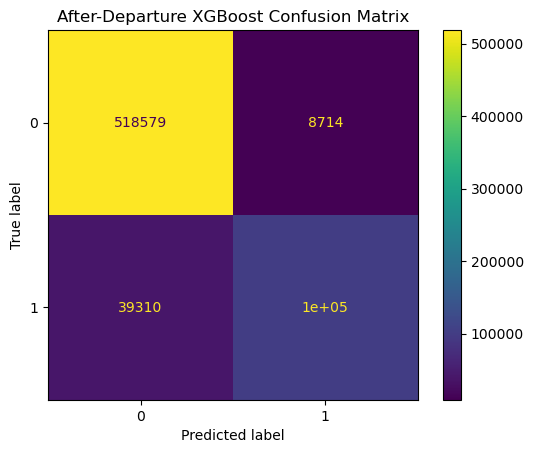

In [17]:
after_departure_xgb_results = evaluate_model(
    model=after_departure_xgb_pipeline,
    X=X_validation,
    y=y_validation,
    model_name="After-Departure XGBoost"
)

In [18]:
after_departure_xgb_results

{'Model': 'After-Departure XGBoost',
 'Accuracy': 0.9280820533094924,
 'Precision': 0.9206895296344838,
 'Recall': 0.7201497850044138,
 'F1': 0.8081648957417912,
 'ROC_AUC': 0.9335282561847428}

## After-Departure Model Results

The validation metrics are displayed in the evaluation output above.

The after-departure model is expected to perform substantially better than the pre-departure models because `DEP_DELAY` directly captures whether the flight has already lost time before becoming airborne.

This improvement must be interpreted carefully. It does not mean that the original pre-departure problem was solved. Instead, the model answers a different operational question using information available immediately after departure.

In [19]:
pre_departure_reference = {
    "Model": "Temporally Tuned Pre-Departure XGBoost",
    "Prediction Moment": "Before departure",
    "Accuracy": 0.624253,
    "Precision": 0.291119,
    "Recall": 0.547890,
    "F1": 0.380213,
    "ROC_AUC": 0.634871
}

model_scenario_comparison = pd.DataFrame([
    pre_departure_reference,
    {
        "Model": after_departure_xgb_results["Model"],
        "Prediction Moment": "Immediately after departure",
        "Accuracy": after_departure_xgb_results["Accuracy"],
        "Precision": after_departure_xgb_results["Precision"],
        "Recall": after_departure_xgb_results["Recall"],
        "F1": after_departure_xgb_results["F1"],
        "ROC_AUC": after_departure_xgb_results["ROC_AUC"]
    }
])

model_scenario_comparison

,Model,Prediction Moment,Accuracy,Precision,Recall,F1,ROC_AUC
0,Temporally Tuned Pre-Departure XGBoost,Before departure,0.624253,0.291119,0.54789,0.380213,0.634871
1,After-Departure XGBoost,Immediately after departure,0.928082,0.920690,0.72015,0.808165,0.933528


## Model Improvement Conclusion

The pre-departure experiments showed that the scheduled-flight and calendar features contained limited predictive signal.

The prediction scenario was therefore changed to an explicitly after-departure scenario. Actual departure information, particularly `DEP_DELAY` and `DEP_TIME`, was added because it is available immediately after the flight leaves the airport.

The validation comparison demonstrates the performance difference between the two prediction moments. The improvement should be attributed to the additional departure information and not to hyperparameter tuning alone.

The after-departure XGBoost configuration is selected for final training and temporal holdout evaluation.

The January–August 2023 holdout is not used for model fitting, tuning, threshold selection, or model comparison. The frozen final pipeline will be scored against it in Notebook 9.